In [1]:
# =====================================================================================
# WHY THIS CELL:
# We have two related datasets:
# 1. student-mat.csv -> Math performance
# 2. student-por.csv -> Portuguese performance
#
# Before doing any ML or deep analysis, we first inspect:
# - whether both datasets load correctly
# - their shapes
# - column similarity
# - missing values
# - duplicate rows
# - basic numeric summaries
# - grade distribution differences
# =====================================================================================

import pandas as pd
from pathlib import Path
from IPython.display import display

print("================================================================================")
print("STEP 1: LOCATING DATASET FILES")
print("================================================================================")

# Kaggle stores datasets inside /kaggle/input/
input_path = Path("/kaggle/input")

# Search automatically for the two files, no need to manually type the full folder path
mat_files = list(input_path.rglob("student-mat.csv"))
por_files = list(input_path.rglob("student-por.csv"))

if len(mat_files) == 0:
    raise FileNotFoundError("student-mat.csv was not found inside /kaggle/input/")
if len(por_files) == 0:
    raise FileNotFoundError("student-por.csv was not found inside /kaggle/input/")

mat_path = mat_files[0]
por_path = por_files[0]

print("Math dataset path:", mat_path)
print("Portuguese dataset path:", por_path)

print("\n================================================================================")
print("STEP 2: LOADING BOTH DATASETS")
print("================================================================================")

# Important: this dataset usually uses semicolon ; as separator, not comma
math_df = pd.read_csv(mat_path, sep=";")
por_df = pd.read_csv(por_path, sep=";")

print("Math dataset loaded successfully.")
print("Portuguese dataset loaded successfully.")

print("\n================================================================================")
print("STEP 3: BASIC SHAPE")
print("================================================================================")

print("Math dataset shape:", math_df.shape)
print("Portuguese dataset shape:", por_df.shape)

print("\nMeaning:")
print("- Rows = number of student records")
print("- Columns = number of variables/features")

print("\n================================================================================")
print("STEP 4: FIRST 5 ROWS OF EACH DATASET")
print("================================================================================")

print("\nMath dataset preview:")
display(math_df.head())

print("\nPortuguese dataset preview:")
display(por_df.head())

print("\n================================================================================")
print("STEP 5: COLUMN COMPARISON")
print("================================================================================")

math_cols = set(math_df.columns)
por_cols = set(por_df.columns)

common_cols = sorted(list(math_cols.intersection(por_cols)))
only_math_cols = sorted(list(math_cols - por_cols))
only_por_cols = sorted(list(por_cols - math_cols))

print("Number of columns in Math dataset:", len(math_df.columns))
print("Number of columns in Portuguese dataset:", len(por_df.columns))
print("Number of common columns:", len(common_cols))

print("\nColumns only in Math dataset:")
print(only_math_cols)

print("\nColumns only in Portuguese dataset:")
print(only_por_cols)

if list(math_df.columns) == list(por_df.columns):
    print("\nResult: Both datasets have exactly the same column names in the same order.")
else:
    print("\nResult: The datasets do not have exactly the same column structure.")

print("\n================================================================================")
print("STEP 6: DATA TYPES")
print("================================================================================")

dtype_comparison = pd.DataFrame({
    "math_dtype": math_df.dtypes,
    "portuguese_dtype": por_df.dtypes
})

display(dtype_comparison)

print("\n================================================================================")
print("STEP 7: MISSING VALUE CHECK")
print("================================================================================")

missing_summary = pd.DataFrame({
    "math_missing_count": math_df.isnull().sum(),
    "math_missing_percent": (math_df.isnull().mean() * 100).round(2),
    "portuguese_missing_count": por_df.isnull().sum(),
    "portuguese_missing_percent": (por_df.isnull().mean() * 100).round(2)
})

display(missing_summary)

print("\nTotal missing values in Math dataset:", math_df.isnull().sum().sum())
print("Total missing values in Portuguese dataset:", por_df.isnull().sum().sum())

print("\n================================================================================")
print("STEP 8: DUPLICATE ROW CHECK")
print("================================================================================")

print("Duplicate rows in Math dataset:", math_df.duplicated().sum())
print("Duplicate rows in Portuguese dataset:", por_df.duplicated().sum())

print("\n================================================================================")
print("STEP 9: NUMERIC COLUMN SUMMARY")
print("================================================================================")

print("\nMath numeric summary:")
display(math_df.describe().T)

print("\nPortuguese numeric summary:")
display(por_df.describe().T)

print("\n================================================================================")
print("STEP 10: CATEGORICAL COLUMN SUMMARY")
print("================================================================================")

math_cat_cols = math_df.select_dtypes(include="object").columns
por_cat_cols = por_df.select_dtypes(include="object").columns

cat_summary = []

for col in math_cat_cols:
    cat_summary.append({
        "column": col,
        "math_unique_values": math_df[col].nunique(),
        "portuguese_unique_values": por_df[col].nunique(),
        "math_values": sorted(math_df[col].unique()),
        "portuguese_values": sorted(por_df[col].unique())
    })

cat_summary_df = pd.DataFrame(cat_summary)
display(cat_summary_df)

print("\n================================================================================")
print("STEP 11: GRADE COLUMN COMPARISON")
print("================================================================================")

grade_cols = ["G1", "G2", "G3"]

grade_comparison = pd.DataFrame({
    "math_mean": math_df[grade_cols].mean(),
    "math_median": math_df[grade_cols].median(),
    "math_min": math_df[grade_cols].min(),
    "math_max": math_df[grade_cols].max(),
    "portuguese_mean": por_df[grade_cols].mean(),
    "portuguese_median": por_df[grade_cols].median(),
    "portuguese_min": por_df[grade_cols].min(),
    "portuguese_max": por_df[grade_cols].max(),
})

display(grade_comparison)

print("\n================================================================================")
print("STEP 12: POSSIBLE OVERLAPPING STUDENTS")
print("================================================================================")

# The README says some students are present in both datasets.
# Since there is no student_id column, we can only estimate overlap by matching identical non-grade attributes.
non_grade_cols = [col for col in common_cols if col not in ["G1", "G2", "G3"]]

math_non_grade = math_df[non_grade_cols].drop_duplicates()
por_non_grade = por_df[non_grade_cols].drop_duplicates()

possible_overlap = math_non_grade.merge(
    por_non_grade,
    on=non_grade_cols,
    how="inner"
)

print("Possible overlapping students based on identical non-grade attributes:", possible_overlap.shape[0])

print("\n================================================================================")
print("DIAGNOSTIC COMPLETE")
print("================================================================================")

print("""
Initial interpretation guide:

1. If both datasets have the same columns, then structurally they are similar.
2. If missing values are zero, we do not need imputation immediately.
3. If Math and Portuguese grade summaries differ, that means subject performance behaves differently.
4. If possible overlap is close to the README value, then our matching logic is reasonable.
5. For now, we are not cleaning, removing outliers, encoding, or training models.
""")

STEP 1: LOCATING DATASET FILES
Math dataset path: /kaggle/input/datasets/adityabatsexemplary/student-performance/student-mat.csv
Portuguese dataset path: /kaggle/input/datasets/adityabatsexemplary/student-performance/student-por.csv

STEP 2: LOADING BOTH DATASETS
Math dataset loaded successfully.
Portuguese dataset loaded successfully.

STEP 3: BASIC SHAPE
Math dataset shape: (395, 33)
Portuguese dataset shape: (649, 33)

Meaning:
- Rows = number of student records
- Columns = number of variables/features

STEP 4: FIRST 5 ROWS OF EACH DATASET

Math dataset preview:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10



Portuguese dataset preview:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13



STEP 5: COLUMN COMPARISON
Number of columns in Math dataset: 33
Number of columns in Portuguese dataset: 33
Number of common columns: 33

Columns only in Math dataset:
[]

Columns only in Portuguese dataset:
[]

Result: Both datasets have exactly the same column names in the same order.

STEP 6: DATA TYPES


...


STEP 10: CATEGORICAL COLUMN SUMMARY


,column,math_unique_values,portuguese_unique_values,math_values,portuguese_values
0,school,2,2,"[GP, MS]","[GP, MS]"
1,sex,2,2,"[F, M]","[F, M]"
2,address,2,2,"[R, U]","[R, U]"
3,famsize,2,2,"[GT3, LE3]","[GT3, LE3]"
4,Pstatus,2,2,"[A, T]","[A, T]"
5,Mjob,5,5,"[at_home, health, other, services, teacher]","[at_home, health, other, services, teacher]"
6,Fjob,5,5,"[at_home, health, other, services, teacher]","[at_home, health, other, services, teacher]"
7,reason,4,4,"[course, home, other, reputation]","[course, home, other, reputation]"
8,guardian,3,3,"[father, mother, other]","[father, mother, other]"
9,schoolsup,2,2,"[no, yes]","[no, yes]"



STEP 11: GRADE COLUMN COMPARISON


,math_mean,math_median,math_min,math_max,portuguese_mean,portuguese_median,portuguese_min,portuguese_max
G1,10.908861,11.0,3,19,11.399076,11.0,0,19
G2,10.713924,11.0,0,19,11.570108,11.0,0,19
G3,10.415190,11.0,0,20,11.906009,12.0,0,19



STEP 12: POSSIBLE OVERLAPPING STUDENTS
Possible overlapping students based on identical non-grade attributes: 39

DIAGNOSTIC COMPLETE

Initial interpretation guide:

1. If both datasets have the same columns, then structurally they are similar.
2. If missing values are zero, we do not need imputation immediately.
3. If Math and Portuguese grade summaries differ, that means subject performance behaves differently.
4. If possible overlap is close to the README value, then our matching logic is reasonable.
5. For now, we are not cleaning, removing outliers, encoding, or training models.



In [2]:
# =====================================================================================
# WHY THIS CELL:
# Before doing analysis or ML, we first check the raw Math dataset for basic data quality.
#
# This cell checks:
# - whether the file loads correctly
# - dataset shape
# - column names and expected structure
# - data types
# - missing values
# - duplicate rows
# - blank/whitespace issues in categorical columns
# - unexpected category values
# - numeric values outside the expected README ranges
# - basic descriptive statistics
#
# Important: We are NOT cleaning or changing the dataset yet.
# =====================================================================================

import pandas as pd
import numpy as np
from IPython.display import display

print("================================================================================")
print("STEP 1: LOAD DATASET")
print("================================================================================")

path = "/kaggle/input/datasets/adityabatsexemplary/student-performance/student-mat.csv"

# This dataset uses semicolon ; as separator
df = pd.read_csv(path, sep=";")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\n================================================================================")
print("STEP 2: COLUMN STRUCTURE CHECK")
print("================================================================================")

expected_columns = [
    "school", "sex", "age", "address", "famsize", "Pstatus",
    "Medu", "Fedu", "Mjob", "Fjob", "reason", "guardian",
    "traveltime", "studytime", "failures",
    "schoolsup", "famsup", "paid", "activities", "nursery",
    "higher", "internet", "romantic",
    "famrel", "freetime", "goout", "Dalc", "Walc",
    "health", "absences", "G1", "G2", "G3"
]

actual_columns = list(df.columns)

print("Number of expected columns:", len(expected_columns))
print("Number of actual columns:", len(actual_columns))

if actual_columns == expected_columns:
    print("Column structure is correct. All expected columns are present in the correct order.")
else:
    print("Column structure issue detected.")
    print("\nColumns missing from dataset:")
    print(set(expected_columns) - set(actual_columns))
    print("\nExtra columns in dataset:")
    print(set(actual_columns) - set(expected_columns))

print("\nActual columns:")
print(actual_columns)

print("\n================================================================================")
print("STEP 3: DATA TYPES CHECK")
print("================================================================================")

dtype_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str),
    "non_null_count": df.notnull().sum().values,
    "unique_values": df.nunique().values
})

display(dtype_summary)

print("\n================================================================================")
print("STEP 4: MISSING VALUE CHECK")
print("================================================================================")

missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": (df.isnull().mean() * 100).round(2)
})

display(missing_summary)

print("Total missing values:", df.isnull().sum().sum())

print("\n================================================================================")
print("STEP 5: DUPLICATE ROW CHECK")
print("================================================================================")

duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

if duplicate_count > 0:
    print("\nDuplicate rows preview:")
    display(df[df.duplicated(keep=False)].head(10))
else:
    print("No exact duplicate rows found.")

print("\n================================================================================")
print("STEP 6: BLANK STRING / WHITESPACE CHECK IN CATEGORICAL COLUMNS")
print("================================================================================")

object_cols = df.select_dtypes(include="object").columns

whitespace_issues = []

for col in object_cols:
    values = df[col].astype(str)
    
    blank_count = (values.str.strip() == "").sum()
    leading_trailing_space_count = (values != values.str.strip()).sum()
    
    whitespace_issues.append({
        "column": col,
        "blank_string_count": blank_count,
        "leading_or_trailing_space_count": leading_trailing_space_count
    })

whitespace_summary = pd.DataFrame(whitespace_issues)
display(whitespace_summary)

print("\n================================================================================")
print("STEP 7: EXPECTED CATEGORY VALUE CHECK")
print("================================================================================")

expected_categories = {
    "school": ["GP", "MS"],
    "sex": ["F", "M"],
    "address": ["U", "R"],
    "famsize": ["LE3", "GT3"],
    "Pstatus": ["T", "A"],
    "Mjob": ["teacher", "health", "services", "at_home", "other"],
    "Fjob": ["teacher", "health", "services", "at_home", "other"],
    "reason": ["home", "reputation", "course", "other"],
    "guardian": ["mother", "father", "other"],
    "schoolsup": ["yes", "no"],
    "famsup": ["yes", "no"],
    "paid": ["yes", "no"],
    "activities": ["yes", "no"],
    "nursery": ["yes", "no"],
    "higher": ["yes", "no"],
    "internet": ["yes", "no"],
    "romantic": ["yes", "no"]
}

category_check = []

for col, expected_vals in expected_categories.items():
    actual_vals = sorted(df[col].dropna().unique())
    unexpected_vals = sorted(list(set(actual_vals) - set(expected_vals)))
    
    category_check.append({
        "column": col,
        "expected_values": expected_vals,
        "actual_values": actual_vals,
        "unexpected_values": unexpected_vals,
        "status": "OK" if len(unexpected_vals) == 0 else "ISSUE"
    })

category_check_df = pd.DataFrame(category_check)
display(category_check_df)

print("\n================================================================================")
print("STEP 8: NUMERIC RANGE CHECK BASED ON README")
print("================================================================================")

expected_ranges = {
    "age": (15, 22),
    "Medu": (0, 4),
    "Fedu": (0, 4),
    "traveltime": (1, 4),
    "studytime": (1, 4),
    "failures": (0, 4),
    "famrel": (1, 5),
    "freetime": (1, 5),
    "goout": (1, 5),
    "Dalc": (1, 5),
    "Walc": (1, 5),
    "health": (1, 5),
    "absences": (0, 93),
    "G1": (0, 20),
    "G2": (0, 20),
    "G3": (0, 20)
}

range_check = []

for col, (min_allowed, max_allowed) in expected_ranges.items():
    below_count = (df[col] < min_allowed).sum()
    above_count = (df[col] > max_allowed).sum()
    
    range_check.append({
        "column": col,
        "min_allowed": min_allowed,
        "max_allowed": max_allowed,
        "actual_min": df[col].min(),
        "actual_max": df[col].max(),
        "below_allowed_count": below_count,
        "above_allowed_count": above_count,
        "status": "OK" if below_count == 0 and above_count == 0 else "ISSUE"
    })

range_check_df = pd.DataFrame(range_check)
display(range_check_df)

print("\n================================================================================")
print("STEP 9: BASIC NUMERIC DESCRIPTIVE ANALYSIS")
print("================================================================================")

display(df.describe().T)

print("\n================================================================================")
print("STEP 10: CATEGORICAL VALUE COUNTS")
print("================================================================================")

for col in object_cols:
    print(f"\nColumn: {col}")
    display(df[col].value_counts(dropna=False).to_frame("count"))

print("\n================================================================================")
print("STEP 11: QUICK GRADE CHECK")
print("================================================================================")

grade_cols = ["G1", "G2", "G3"]

grade_summary = pd.DataFrame({
    "mean": df[grade_cols].mean(),
    "median": df[grade_cols].median(),
    "std": df[grade_cols].std(),
    "min": df[grade_cols].min(),
    "max": df[grade_cols].max(),
    "zero_count": (df[grade_cols] == 0).sum()
})

display(grade_summary)

print("\n================================================================================")
print("DATA QUALITY AUDIT COMPLETE")
print("================================================================================")

print("""
Interpretation guide:

1. If missing values = 0, then imputation is not needed immediately.
2. If duplicate rows = 0, then exact duplicate removal is not needed.
3. If category checks are OK, categorical columns are properly formatted.
4. If range checks are OK, numeric columns follow the README rules.
5. If G1/G2/G3 have zeros, those may represent very poor/failing grades or special cases.
   We should inspect them later, but not remove them immediately.
""")

STEP 1: LOAD DATASET
Dataset loaded successfully.
Shape: (395, 33)

First 5 rows:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10



STEP 2: COLUMN STRUCTURE CHECK
Number of expected columns: 33
Number of actual columns: 33
Column structure is correct. All expected columns are present in the correct order.

Actual columns:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

STEP 3: DATA TYPES CHECK


,column,dtype,non_null_count,unique_values
school,school,object,395,2
sex,sex,object,395,2
age,age,int64,395,8
address,address,object,395,2
famsize,famsize,object,395,2
Pstatus,Pstatus,object,395,2
Medu,Medu,int64,395,5
Fedu,Fedu,int64,395,5
Mjob,Mjob,object,395,5
Fjob,Fjob,object,395,5



STEP 4: MISSING VALUE CHECK


...


Column: romantic


,count
romantic,
no,263
yes,132



STEP 11: QUICK GRADE CHECK


,mean,median,std,min,max,zero_count
G1,10.908861,11.0,3.319195,3,19,0
G2,10.713924,11.0,3.761505,0,19,13
G3,10.415190,11.0,4.581443,0,20,38



DATA QUALITY AUDIT COMPLETE

Interpretation guide:

1. If missing values = 0, then imputation is not needed immediately.
2. If duplicate rows = 0, then exact duplicate removal is not needed.
3. If category checks are OK, categorical columns are properly formatted.
4. If range checks are OK, numeric columns follow the README rules.
5. If G1/G2/G3 have zeros, those may represent very poor/failing grades or special cases.
   We should inspect them later, but not remove them immediately.



STEP 1: LOAD MATH DATASET
Dataset loaded successfully.
Shape: (395, 33)

Target selected: G1
Meaning: First-period Math grade

STEP 2: BASIC SUMMARY OF G1


,count,mean,median,std,min,25%,50%,75%,max,skewness
0,395,10.909,11.0,3.319,3,8.0,11.0,13.0,19,0.241



Interpretation hints:
- Mean tells the average first-period Math grade.
- Median tells the middle student's grade.
- Std tells how spread out the grades are.
- Skewness tells whether the distribution leans more toward low or high scores.

STEP 3: COUNT OF EACH G1 GRADE


,G1_grade,student_count
0,3,1
1,4,1
2,5,7
3,6,24
4,7,37
5,8,41
6,9,31
7,10,51
8,11,39
9,12,35



STEP 4: HISTOGRAM OF G1


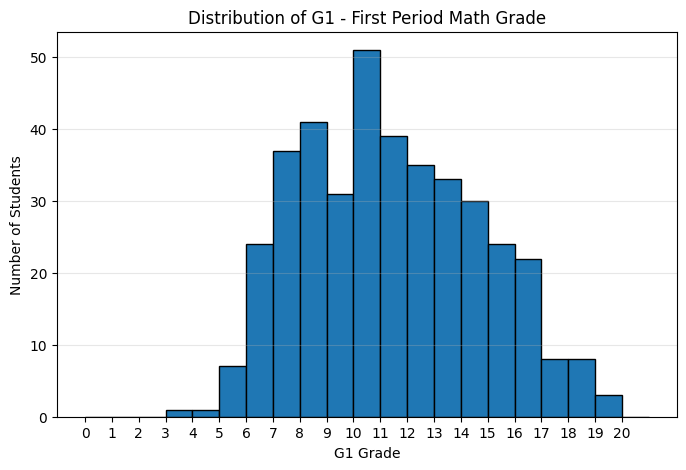


STEP 5: BOX PLOT OF G1


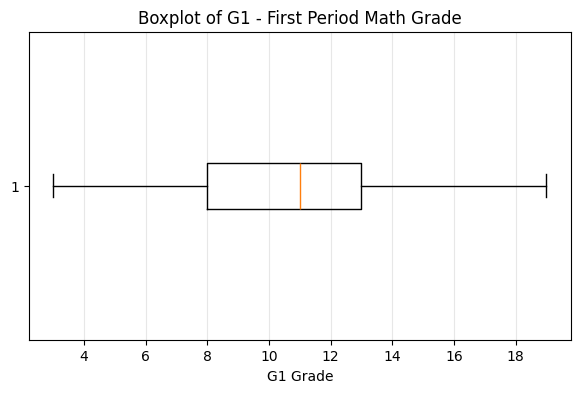


STEP 6: BAR PLOT OF EXACT GRADE COUNTS


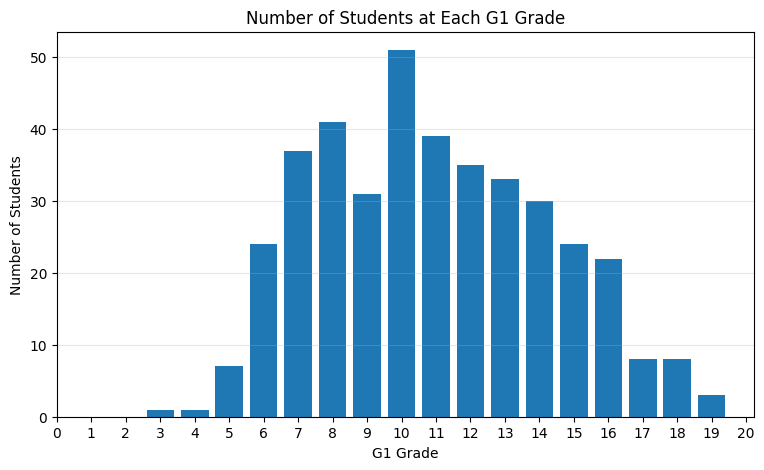


STEP 7: ROUGH PERFORMANCE BANDS


,G1_band,student_count,percentage
0,Low / Below 10,142,35.95
1,Medium / 10 to 13,158,40.00
2,High / 14 and above,95,24.05


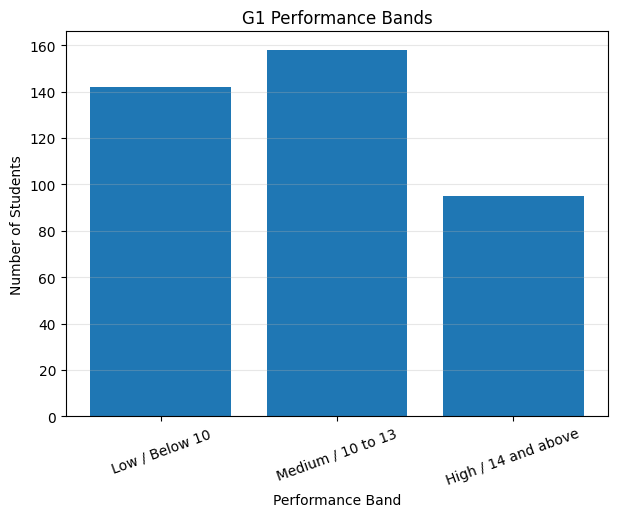


G1 TARGET ANALYSIS COMPLETE

What we learned from this cell:
1. The central level of G1 performance.
2. How spread out the first-period grades are.
3. Whether most students are low, medium, or high performers.
4. Whether G1 has unusual extreme values.
5. Whether G1 is suitable as a target for further analysis.



In [3]:
# =====================================================================================
# WHY THIS CELL:
# We have chosen G1 as our target variable.
#
# Before checking which features are associated with G1, we first understand G1 itself:
# - basic summary statistics
# - distribution of grades
# - count of each grade value
# - spread using boxplot
# - rough performance bands
#
# Important:
# We are NOT analyzing other features yet.
# We are NOT using G2 and G3 yet.
# =====================================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

print("================================================================================")
print("STEP 1: LOAD MATH DATASET")
print("================================================================================")

path = "/kaggle/input/datasets/adityabatsexemplary/student-performance/student-mat.csv"
df = pd.read_csv(path, sep=";")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

target = "G1"

print("\nTarget selected:", target)
print("Meaning: First-period Math grade")

print("\n================================================================================")
print("STEP 2: BASIC SUMMARY OF G1")
print("================================================================================")

g1_summary = pd.DataFrame({
    "count": [df[target].count()],
    "mean": [df[target].mean()],
    "median": [df[target].median()],
    "std": [df[target].std()],
    "min": [df[target].min()],
    "25%": [df[target].quantile(0.25)],
    "50%": [df[target].quantile(0.50)],
    "75%": [df[target].quantile(0.75)],
    "max": [df[target].max()],
    "skewness": [df[target].skew()]
})

display(g1_summary.round(3))

print("\nInterpretation hints:")
print("- Mean tells the average first-period Math grade.")
print("- Median tells the middle student's grade.")
print("- Std tells how spread out the grades are.")
print("- Skewness tells whether the distribution leans more toward low or high scores.")

print("\n================================================================================")
print("STEP 3: COUNT OF EACH G1 GRADE")
print("================================================================================")

grade_counts = (
    df[target]
    .value_counts()
    .sort_index()
    .rename_axis("G1_grade")
    .reset_index(name="student_count")
)

display(grade_counts)

print("\n================================================================================")
print("STEP 4: HISTOGRAM OF G1")
print("================================================================================")

plt.figure(figsize=(8, 5))
plt.hist(df[target], bins=range(0, 22), edgecolor="black")
plt.title("Distribution of G1 - First Period Math Grade")
plt.xlabel("G1 Grade")
plt.ylabel("Number of Students")
plt.xticks(range(0, 21))
plt.grid(axis="y", alpha=0.3)
plt.show()

print("\n================================================================================")
print("STEP 5: BOX PLOT OF G1")
print("================================================================================")

plt.figure(figsize=(7, 4))
plt.boxplot(df[target], vert=False)
plt.title("Boxplot of G1 - First Period Math Grade")
plt.xlabel("G1 Grade")
plt.grid(axis="x", alpha=0.3)
plt.show()

print("\n================================================================================")
print("STEP 6: BAR PLOT OF EXACT GRADE COUNTS")
print("================================================================================")

plt.figure(figsize=(9, 5))
plt.bar(grade_counts["G1_grade"], grade_counts["student_count"])
plt.title("Number of Students at Each G1 Grade")
plt.xlabel("G1 Grade")
plt.ylabel("Number of Students")
plt.xticks(range(0, 21))
plt.grid(axis="y", alpha=0.3)
plt.show()

print("\n================================================================================")
print("STEP 7: ROUGH PERFORMANCE BANDS")
print("================================================================================")

# These bands are only for intuitive analysis.
# Dataset grades are from 0 to 20.
# In many 0-20 grading systems, 10 is treated as an approximate passing threshold.

def grade_band(score):
    if score < 10:
        return "Low / Below 10"
    elif score < 14:
        return "Medium / 10 to 13"
    else:
        return "High / 14 and above"

df["G1_band"] = df[target].apply(grade_band)

band_summary = (
    df["G1_band"]
    .value_counts()
    .reindex(["Low / Below 10", "Medium / 10 to 13", "High / 14 and above"])
    .reset_index()
)

band_summary.columns = ["G1_band", "student_count"]
band_summary["percentage"] = (band_summary["student_count"] / len(df) * 100).round(2)

display(band_summary)

plt.figure(figsize=(7, 5))
plt.bar(band_summary["G1_band"], band_summary["student_count"])
plt.title("G1 Performance Bands")
plt.xlabel("Performance Band")
plt.ylabel("Number of Students")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.show()

print("\n================================================================================")
print("G1 TARGET ANALYSIS COMPLETE")
print("================================================================================")

print("""
What we learned from this cell:
1. The central level of G1 performance.
2. How spread out the first-period grades are.
3. Whether most students are low, medium, or high performers.
4. Whether G1 has unusual extreme values.
5. Whether G1 is suitable as a target for further analysis.
""")

STEP 1: LOAD DATASET
Dataset loaded successfully.
Shape: (395, 33)
Target selected: G1

STEP 2: DEFINE ORDINAL / RATING-LIKE FEATURES
Ordinal/rating-like features selected:
- Medu: Mother's education
- Fedu: Father's education
- traveltime: Home to school travel time
- studytime: Weekly study time
- failures: Past class failures
- famrel: Family relationship quality
- freetime: Free time after school
- goout: Going out with friends
- Dalc: Workday alcohol consumption
- Walc: Weekend alcohol consumption
- health: Current health status

STEP 3: LEVEL-WISE G1 SUMMARY FOR EACH ORDINAL FEATURE


,feature,meaning,Medu,student_count,mean_G1,median_G1,std_G1,min_G1,max_G1,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health
0,Medu,Mother's education,0.0,3,12.000,13.0,4.583,7,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Medu,Mother's education,1.0,59,9.746,9.0,3.043,5,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Medu,Mother's education,2.0,103,10.563,10.0,2.939,5,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Medu,Mother's education,3.0,99,10.606,11.0,3.519,3,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Medu,Mother's education,4.0,131,11.908,12.0,3.318,5,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Fedu,Father's education,NaN,2,12.000,12.0,1.414,11,13,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Fedu,Father's education,NaN,82,9.732,9.0,3.274,5,18,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Fedu,Father's education,NaN,115,11.026,11.0,3.219,5,18,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Fedu,Father's education,NaN,100,10.740,10.0,3.224,3,19,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Fedu,Father's education,NaN,96,11.927,12.0,3.309,5,19,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



How to read this table:
- For each feature, check whether mean_G1 rises, falls, or stays flat as the feature level changes.
- Also check student_count. A level with very few students can give unstable averages.

STEP 4: SPEARMAN CORRELATION WITH G1


,feature,meaning,spearman_corr_with_G1,pearson_corr_with_G1,lowest_level_mean_G1,highest_level_mean_G1,mean_G1_range
4,failures,Past class failures,-0.346,-0.355,6.938,11.468,4.530
0,Medu,Mother's education,0.210,0.205,9.746,12.000,2.254
1,Fedu,Father's education,0.195,0.190,9.732,12.000,2.268
3,studytime,Weekly study time,0.162,0.161,10.438,12.046,1.608
7,goout,Going out with friends,-0.152,-0.149,9.792,11.369,1.576
8,Dalc,Workday alcohol consumption,-0.111,-0.094,9.778,11.156,1.378
9,Walc,Weekend alcohol consumption,-0.108,-0.126,9.964,11.271,1.306
2,traveltime,Home to school travel time,-0.086,-0.093,8.875,11.097,2.222
10,health,Current health status,-0.052,-0.073,10.604,11.702,1.098
5,famrel,Family relationship quality,0.026,0.022,10.559,11.222,0.663



Interpretation guide:
- Positive Spearman: higher feature level tends to go with higher G1.
- Negative Spearman: higher feature level tends to go with lower G1.
- Near 0: no strong ordered pattern.
- mean_G1_range shows how much average G1 changes across feature levels.

STEP 5: PLOT AVERAGE G1 BY EACH ORDINAL FEATURE


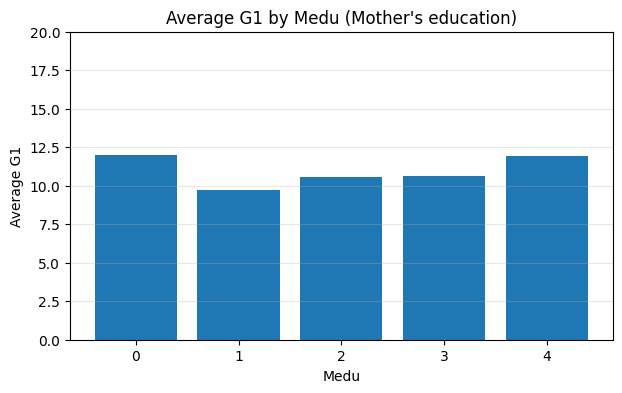

Student counts for Medu:


,level,mean_G1,student_count
0,0,12.000000,3
1,1,9.745763,59
2,2,10.563107,103
3,3,10.606061,99
4,4,11.908397,131


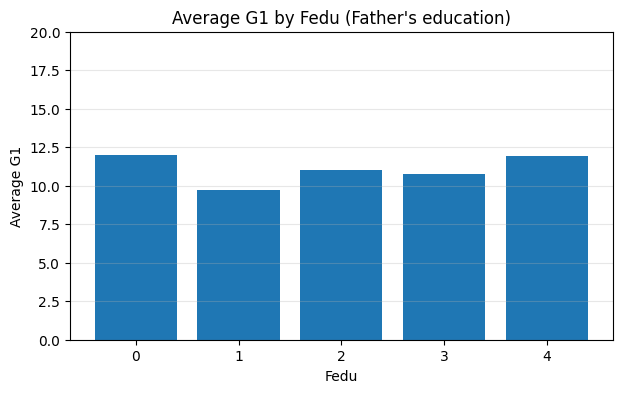

Student counts for Fedu:


,level,mean_G1,student_count
0,0,12.000000,2
1,1,9.731707,82
2,2,11.026087,115
3,3,10.740000,100
4,4,11.927083,96


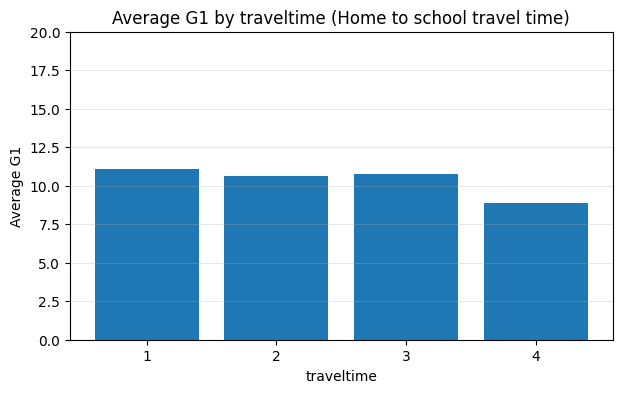

Student counts for traveltime:


,level,mean_G1,student_count
0,1,11.097276,257
1,2,10.644860,107
2,3,10.739130,23
3,4,8.875000,8


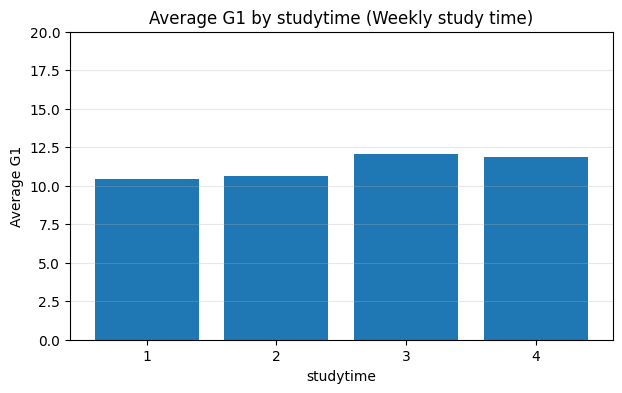

Student counts for studytime:


,level,mean_G1,student_count
0,1,10.438095,105
1,2,10.651515,198
2,3,12.046154,65
3,4,11.888889,27


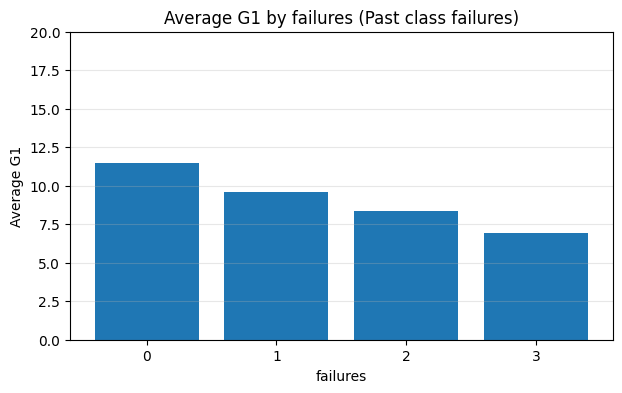

Student counts for failures:


,level,mean_G1,student_count
0,0,11.467949,312
1,1,9.560000,50
2,2,8.352941,17
3,3,6.937500,16


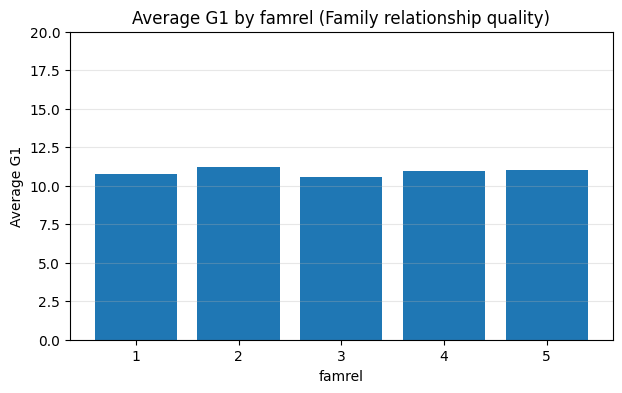

Student counts for famrel:


,level,mean_G1,student_count
0,1,10.750000,8
1,2,11.222222,18
2,3,10.558824,68
3,4,10.958974,195
4,5,11.000000,106


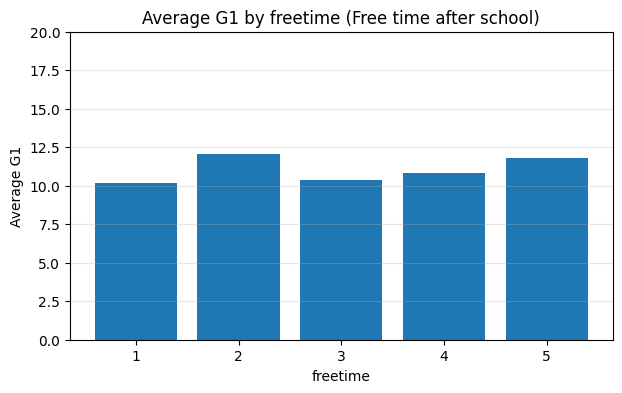

Student counts for freetime:


,level,mean_G1,student_count
0,1,10.157895,19
1,2,12.046875,64
2,3,10.369427,157
3,4,10.834783,115
4,5,11.775000,40


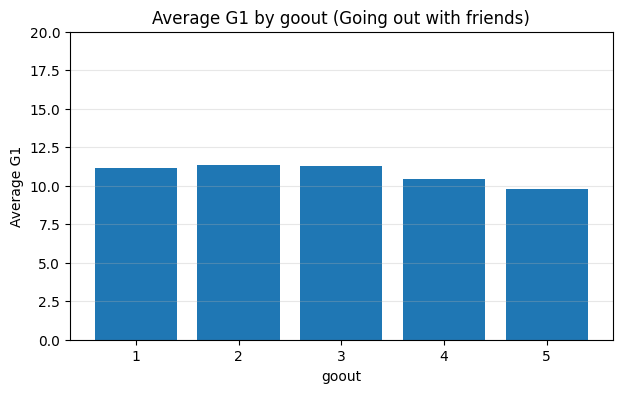

Student counts for goout:


,level,mean_G1,student_count
0,1,11.130435,23
1,2,11.368932,103
2,3,11.276923,130
3,4,10.430233,86
4,5,9.792453,53


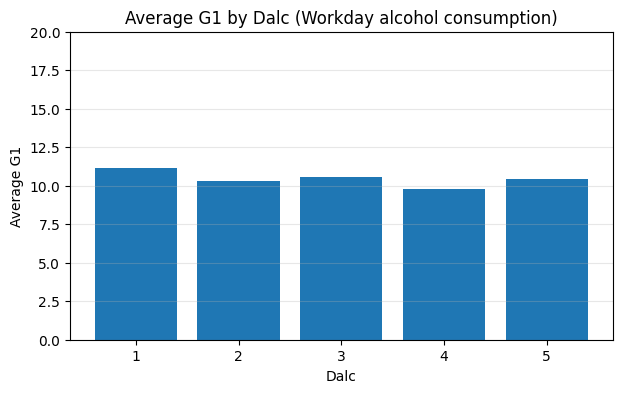

Student counts for Dalc:


,level,mean_G1,student_count
0,1,11.155797,276
1,2,10.306667,75
2,3,10.576923,26
3,4,9.777778,9
4,5,10.444444,9


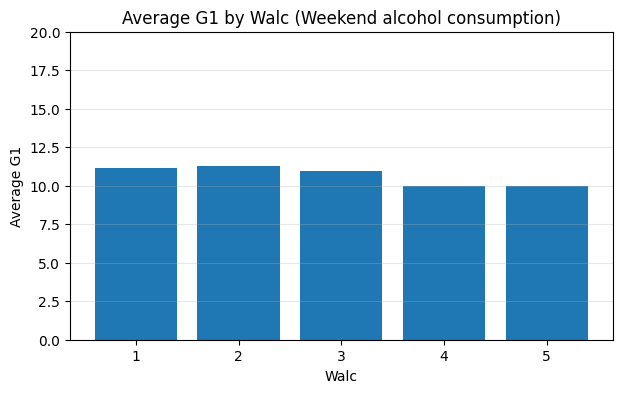

Student counts for Walc:


,level,mean_G1,student_count
0,1,11.178808,151
1,2,11.270588,85
2,3,10.937500,80
3,4,9.980392,51
4,5,9.964286,28


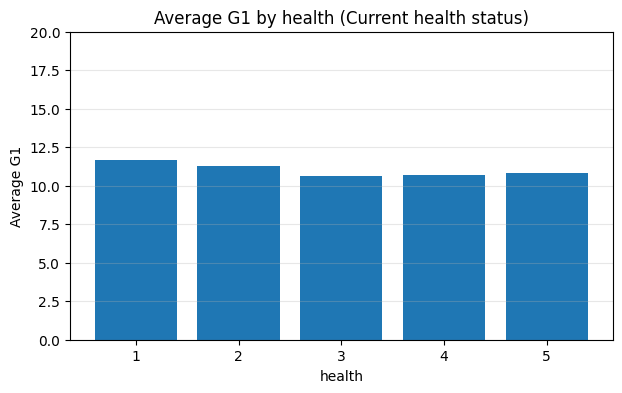

Student counts for health:


,level,mean_G1,student_count
0,1,11.702128,47
1,2,11.288889,45
2,3,10.604396,91
3,4,10.727273,66
4,5,10.808219,146



ORDINAL FEATURE VS G1 ANALYSIS COMPLETE

What to look for:

1. Which features have a clear upward or downward pattern?
   Example: if failures increases and G1 drops, that is a strong negative association.

2. Which features have almost flat average G1?
   That means the feature may not be strongly associated with G1 by itself.

3. Which features have tiny groups?
   Be careful. A group with 3 students can distort the average.

4. Which features have stronger Spearman correlation?
   Those are the first candidates for deeper analysis.

Remember:
This is still association, not causation.



In [4]:
# =====================================================================================
# WHY THIS CELL:
# We have selected G1 as the target.
#
# Now we begin bivariate analysis:
# one ordered/ordinal feature vs G1.
#
# These columns are numeric, but most are not truly continuous.
# They are ordered categories / rating scales.
#
# This cell checks:
# - average G1 at each level of each ordinal feature
# - median G1 at each level
# - number of students at each level
# - Spearman correlation with G1
# - rough difference between highest and lowest average G1
#
# Important:
# - We are excluding G2 and G3 because they happen after G1.
# - We are not proving causation.
# - We are only checking association/pattern.
# =====================================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

print("================================================================================")
print("STEP 1: LOAD DATASET")
print("================================================================================")

path = "/kaggle/input/datasets/adityabatsexemplary/student-performance/student-mat.csv"
df = pd.read_csv(path, sep=";")

target = "G1"

print("Dataset loaded successfully.")
print("Shape:", df.shape)
print("Target selected:", target)

print("\n================================================================================")
print("STEP 2: DEFINE ORDINAL / RATING-LIKE FEATURES")
print("================================================================================")

ordinal_features = [
    "Medu",        # mother's education
    "Fedu",        # father's education
    "traveltime",  # travel time
    "studytime",   # weekly study time
    "failures",    # past class failures
    "famrel",      # family relationship quality
    "freetime",    # free time after school
    "goout",       # going out with friends
    "Dalc",        # workday alcohol consumption
    "Walc",        # weekend alcohol consumption
    "health"       # current health status
]

feature_meanings = {
    "Medu": "Mother's education",
    "Fedu": "Father's education",
    "traveltime": "Home to school travel time",
    "studytime": "Weekly study time",
    "failures": "Past class failures",
    "famrel": "Family relationship quality",
    "freetime": "Free time after school",
    "goout": "Going out with friends",
    "Dalc": "Workday alcohol consumption",
    "Walc": "Weekend alcohol consumption",
    "health": "Current health status"
}

print("Ordinal/rating-like features selected:")
for col in ordinal_features:
    print(f"- {col}: {feature_meanings[col]}")

print("\n================================================================================")
print("STEP 3: LEVEL-WISE G1 SUMMARY FOR EACH ORDINAL FEATURE")
print("================================================================================")

all_level_summaries = []

for col in ordinal_features:
    summary = (
        df.groupby(col)[target]
        .agg(
            student_count="count",
            mean_G1="mean",
            median_G1="median",
            std_G1="std",
            min_G1="min",
            max_G1="max"
        )
        .reset_index()
    )
    
    summary.insert(0, "feature", col)
    summary.insert(1, "meaning", feature_meanings[col])
    
    all_level_summaries.append(summary)

ordinal_level_summary = pd.concat(all_level_summaries, ignore_index=True)

display(ordinal_level_summary.round(3))

print("\nHow to read this table:")
print("- For each feature, check whether mean_G1 rises, falls, or stays flat as the feature level changes.")
print("- Also check student_count. A level with very few students can give unstable averages.")

print("\n================================================================================")
print("STEP 4: SPEARMAN CORRELATION WITH G1")
print("================================================================================")

spearman_results = []

for col in ordinal_features:
    spearman_corr = df[[col, target]].corr(method="spearman").loc[col, target]
    pearson_corr = df[[col, target]].corr(method="pearson").loc[col, target]
    
    level_means = df.groupby(col)[target].mean()
    mean_g1_range = level_means.max() - level_means.min()
    
    spearman_results.append({
        "feature": col,
        "meaning": feature_meanings[col],
        "spearman_corr_with_G1": spearman_corr,
        "pearson_corr_with_G1": pearson_corr,
        "lowest_level_mean_G1": level_means.min(),
        "highest_level_mean_G1": level_means.max(),
        "mean_G1_range": mean_g1_range
    })

ordinal_corr_summary = pd.DataFrame(spearman_results)

ordinal_corr_summary["abs_spearman"] = ordinal_corr_summary["spearman_corr_with_G1"].abs()

ordinal_corr_summary = ordinal_corr_summary.sort_values(
    by="abs_spearman",
    ascending=False
).drop(columns="abs_spearman")

display(ordinal_corr_summary.round(3))

print("\nInterpretation guide:")
print("- Positive Spearman: higher feature level tends to go with higher G1.")
print("- Negative Spearman: higher feature level tends to go with lower G1.")
print("- Near 0: no strong ordered pattern.")
print("- mean_G1_range shows how much average G1 changes across feature levels.")

print("\n================================================================================")
print("STEP 5: PLOT AVERAGE G1 BY EACH ORDINAL FEATURE")
print("================================================================================")

for col in ordinal_features:
    plot_data = (
        df.groupby(col)[target]
        .agg(mean_G1="mean", student_count="count")
        .reset_index()
        .sort_values(col)
    )
    
    plt.figure(figsize=(7, 4))
    plt.bar(plot_data[col].astype(str), plot_data["mean_G1"])
    plt.title(f"Average G1 by {col} ({feature_meanings[col]})")
    plt.xlabel(col)
    plt.ylabel("Average G1")
    plt.ylim(0, 20)
    plt.grid(axis="y", alpha=0.3)
    plt.show()
    
    print(f"Student counts for {col}:")
    display(plot_data.rename(columns={col: "level"}))

print("\n================================================================================")
print("ORDINAL FEATURE VS G1 ANALYSIS COMPLETE")
print("================================================================================")

print("""
What to look for:

1. Which features have a clear upward or downward pattern?
   Example: if failures increases and G1 drops, that is a strong negative association.

2. Which features have almost flat average G1?
   That means the feature may not be strongly associated with G1 by itself.

3. Which features have tiny groups?
   Be careful. A group with 3 students can distort the average.

4. Which features have stronger Spearman correlation?
   Those are the first candidates for deeper analysis.

Remember:
This is still association, not causation.
""")